First 5 rows of Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset shape: (150, 4)


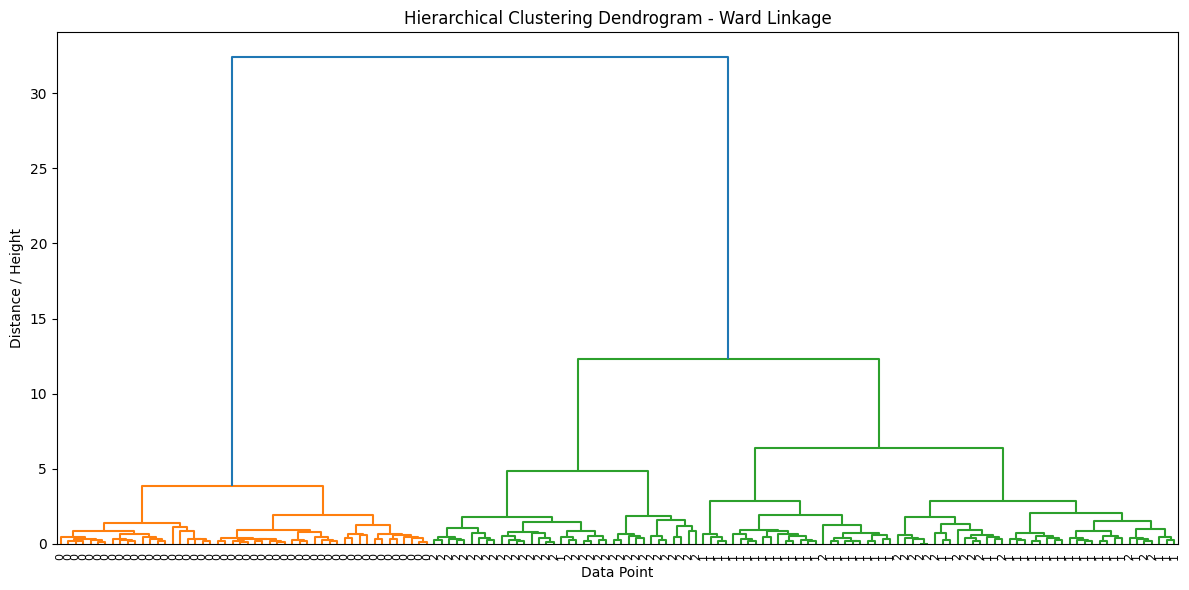

In [45]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load Iris dataset
iris = load_iris()

# Get feature data
X = iris.data

# Create DataFrame for better understanding
df = pd.DataFrame(X, columns=iris.feature_names)

print("First 5 rows of Iris dataset:")
print(df.head())

print("\nDataset shape:", X.shape)
# Perform hierarchical clustering using Ward linkage
Z_ward = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    Z_ward,
    labels=iris.target,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Data Point")
plt.ylabel("Distance / Height")
plt.tight_layout()
plt.show()

Cluster labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 2 2 2 2 3 2 2 2 2
 2 2 3 3 2 2 2 2 3 2 3 2 3 2 2 3 3 2 2 2 2 2 3 3 2 2 2 3 2 2 2 3 2 2 2 3 2
 2 3]

Number of samples in each cluster:
Cluster
1    50
2    36
3    64
Name: count, dtype: int64


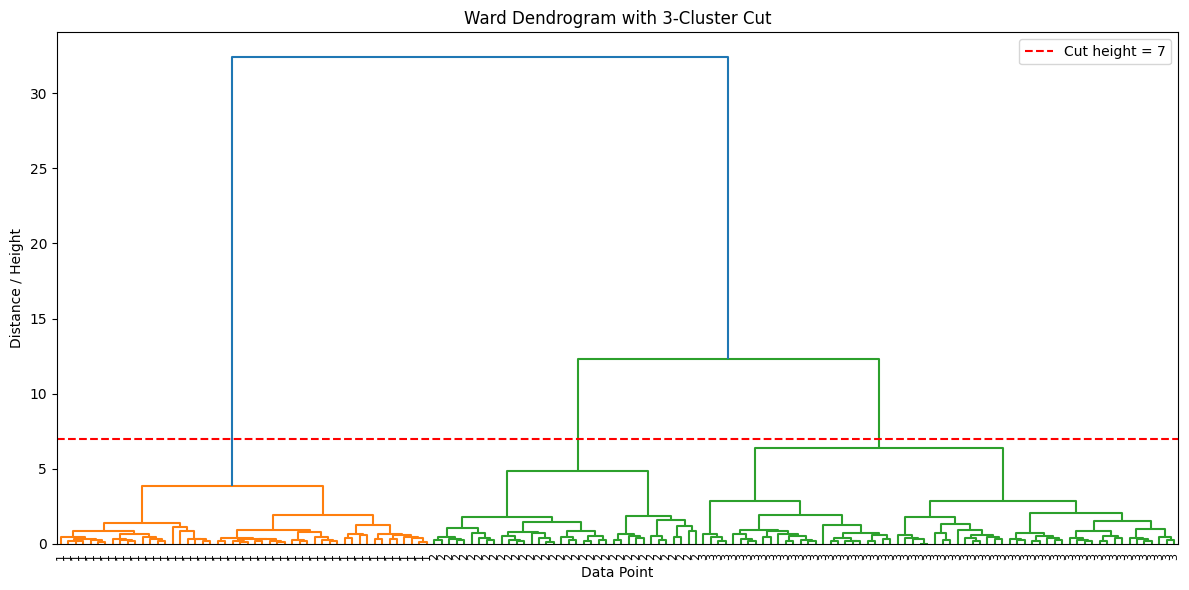

In [47]:
# Cut the Ward dendrogram to obtain 3 clusters
# A distance threshold around 7 gives 3 clusters for Iris
cluster_labels = fcluster(
    Z_ward,
    t=7,
    criterion='distance'
)

# Add cluster labels to the DataFrame
df["Cluster"] = cluster_labels

# Print cluster assignments
print("Cluster labels:")
print(cluster_labels)

# Count samples in each cluster
cluster_counts = df["Cluster"].value_counts().sort_index()

print("\nNumber of samples in each cluster:")
print(cluster_counts)
plt.figure(figsize=(12, 6))

dendrogram(
    Z_ward,
    labels=cluster_labels,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.axhline(
    y=7,
    color='red',
    linestyle='--',
    label='Cut height = 7'
)

plt.title("Ward Dendrogram with 3-Cluster Cut")
plt.xlabel("Data Point")
plt.ylabel("Distance / Height")
plt.legend()
plt.tight_layout()
plt.show()

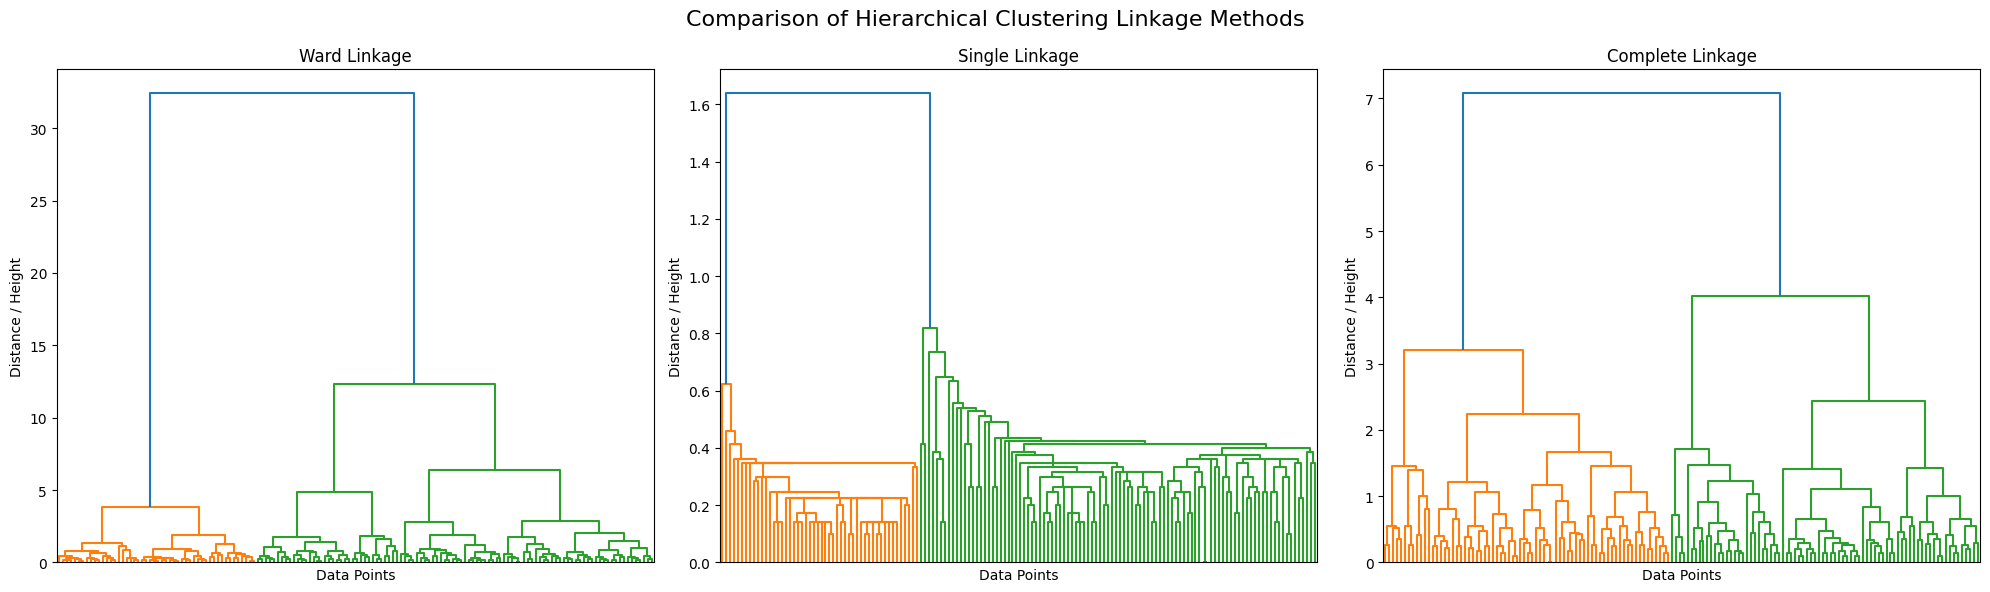

In [48]:
# Perform clustering using three different linkage methods
Z_ward = linkage(X, method='ward')
Z_single = linkage(X, method='single')
Z_complete = linkage(X, method='complete')

# Create three side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Ward linkage
dendrogram(
    Z_ward,
    ax=axes[0],
    no_labels=True
)
axes[0].set_title("Ward Linkage")
axes[0].set_xlabel("Data Points")
axes[0].set_ylabel("Distance / Height")

# Single linkage
dendrogram(
    Z_single,
    ax=axes[1],
    no_labels=True
)
axes[1].set_title("Single Linkage")
axes[1].set_xlabel("Data Points")
axes[1].set_ylabel("Distance / Height")

# Complete linkage
dendrogram(
    Z_complete,
    ax=axes[2],
    no_labels=True
)
axes[2].set_title("Complete Linkage")
axes[2].set_xlabel("Data Points")
axes[2].set_ylabel("Distance / Height")

plt.suptitle(
    "Comparison of Hierarchical Clustering Linkage Methods",
    fontsize=16
)

plt.tight_layout()
plt.show()

Iris Dataset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset shape: (150, 4)


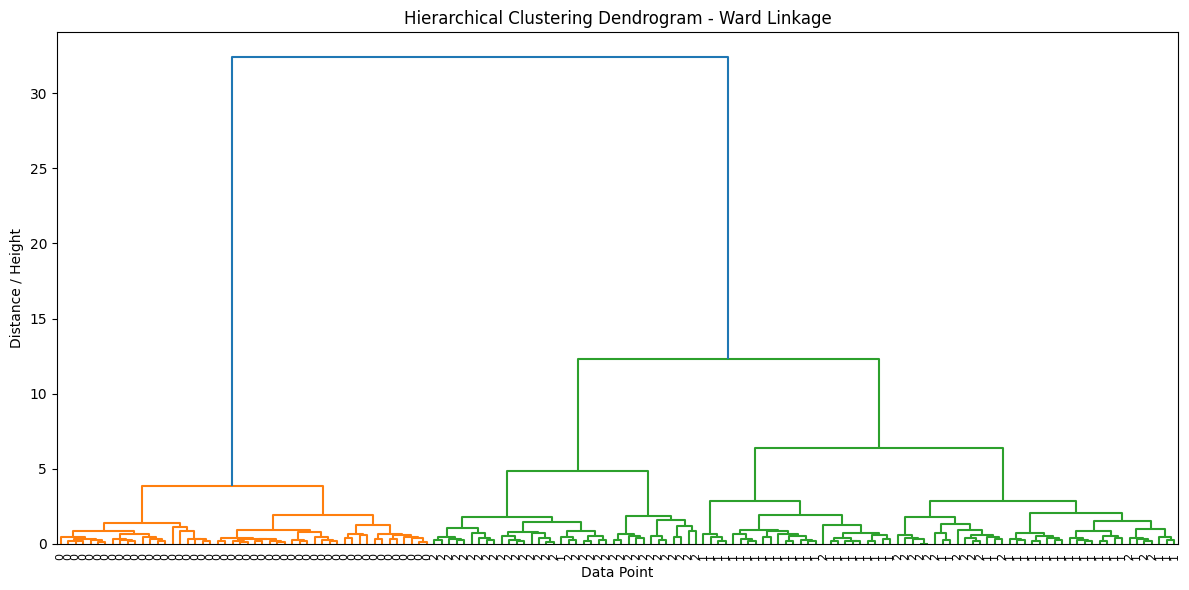


Cluster assignments:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 2 2 2 2 3 2 2 2 2
 2 2 3 3 2 2 2 2 3 2 3 2 3 2 2 3 3 2 2 2 2 2 3 3 2 2 2 3 2 2 2 3 2 2 2 3 2
 2 3]

Number of samples in each cluster:
Cluster
1    50
2    36
3    64
Name: count, dtype: int64


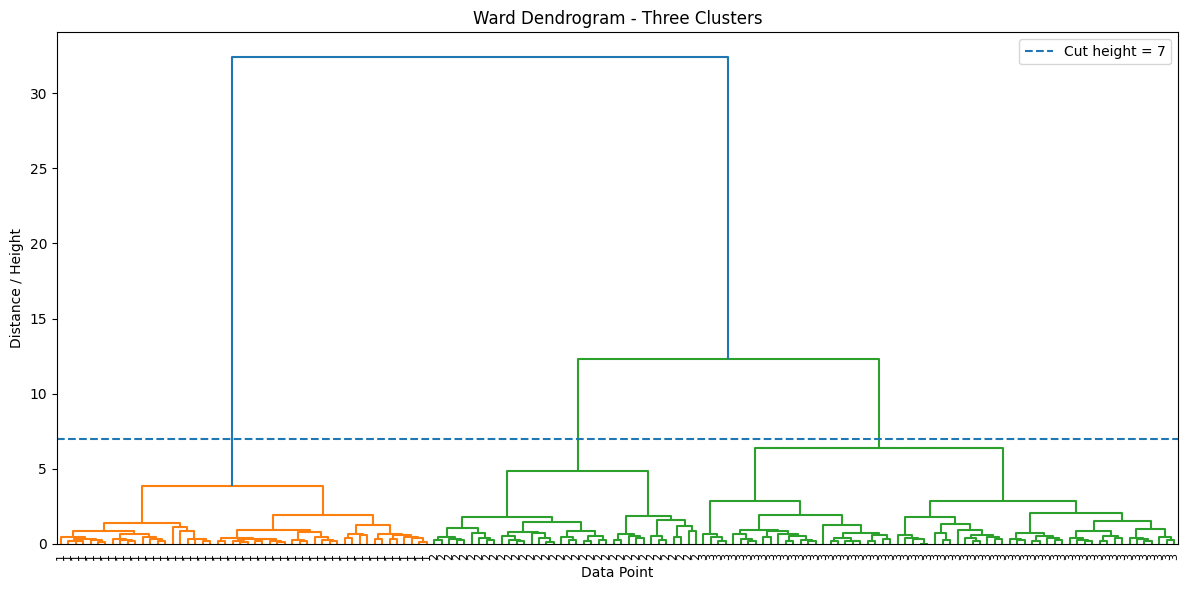

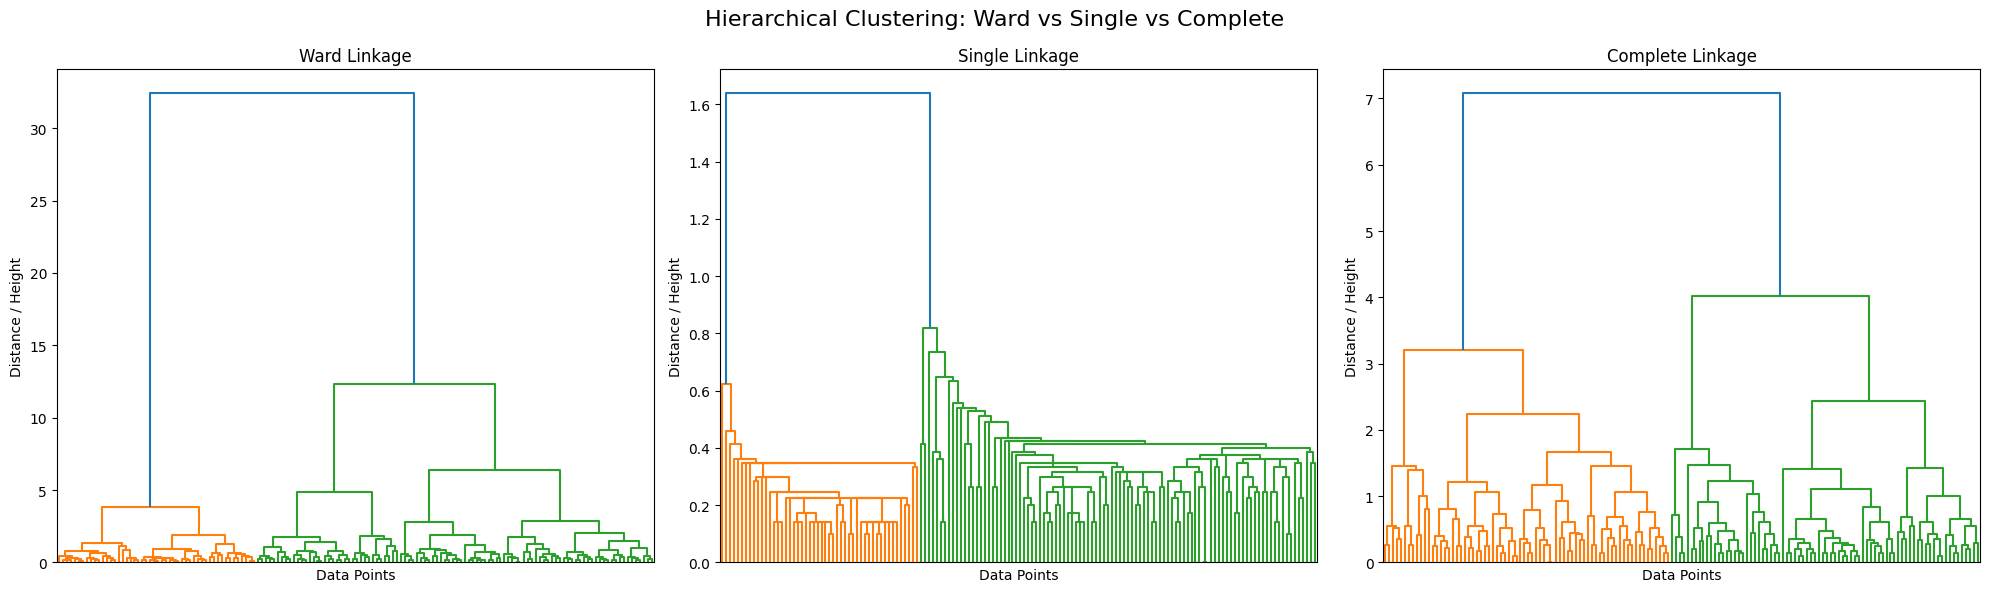


Clustered dataset saved as: iris_with_clusters.csv


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ==========================================================
# 1. LOAD IRIS DATASET
# ==========================================================

iris = load_iris()
X = iris.data

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

print("Iris Dataset")
print("=" * 50)
print(df.head())

print("\nDataset shape:", X.shape)


# ==========================================================
# 2. WARD HIERARCHICAL CLUSTERING
# ==========================================================

Z_ward = linkage(X, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(
    Z_ward,
    labels=iris.target,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Data Point")
plt.ylabel("Distance / Height")
plt.tight_layout()
plt.show()


# ==========================================================
# CUT DENDROGRAM INTO 3 CLUSTERS
# ==========================================================

# Distance threshold selected from the dendrogram
threshold = 7

cluster_labels = fcluster(
    Z_ward,
    t=threshold,
    criterion='distance'
)

df["Cluster"] = cluster_labels

print("\nCluster assignments:")
print(cluster_labels)

print("\nNumber of samples in each cluster:")
print(df["Cluster"].value_counts().sort_index())


# Plot Ward dendrogram with cut line
plt.figure(figsize=(12, 6))

dendrogram(
    Z_ward,
    labels=cluster_labels,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.axhline(
    y=threshold,
    linestyle='--',
    label=f'Cut height = {threshold}'
)

plt.title("Ward Dendrogram - Three Clusters")
plt.xlabel("Data Point")
plt.ylabel("Distance / Height")
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================================
# 3. SINGLE AND COMPLETE LINKAGE
# ==========================================================

Z_single = linkage(X, method='single')
Z_complete = linkage(X, method='complete')


# ==========================================================
# SIDE-BY-SIDE COMPARISON
# ==========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6)
)

# Ward
dendrogram(
    Z_ward,
    ax=axes[0],
    no_labels=True
)

axes[0].set_title("Ward Linkage")
axes[0].set_xlabel("Data Points")
axes[0].set_ylabel("Distance / Height")


# Single
dendrogram(
    Z_single,
    ax=axes[1],
    no_labels=True
)

axes[1].set_title("Single Linkage")
axes[1].set_xlabel("Data Points")
axes[1].set_ylabel("Distance / Height")


# Complete
dendrogram(
    Z_complete,
    ax=axes[2],
    no_labels=True
)

axes[2].set_title("Complete Linkage")
axes[2].set_xlabel("Data Points")
axes[2].set_ylabel("Distance / Height")


plt.suptitle(
    "Hierarchical Clustering: Ward vs Single vs Complete",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ==========================================================
# 4. OPTIONAL: SAVE DATA WITH CLUSTER LABELS
# ==========================================================

df.to_csv(
    "iris_with_clusters.csv",
    index=False
)

print("\nClustered dataset saved as: iris_with_clusters.csv")